# Vehicle Loan Default Prediction
## Banking — Course-End Project 2
### EDA + Logistic Regression Modeling
---

## Step 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)

plt.style.use('seaborn-v0_8-whitegrid')
print('Libraries imported successfully!')

Libraries imported successfully!


## Step 2 — Load Data & Preliminary Inspection

In [3]:
# Load dataset
from google.colab import drive
drive.mount('/content/drive')
from google.colab import files
uploaded = files.upload()
df = pd.read_excel('data.xlsx')
print('Shape:', df.shape)
print('\nFirst 5 rows:')
df.head()

Mounted at /content/drive


Saving data.xlsx to data.xlsx
Shape: (233154, 41)

First 5 rows:


,UniqueID,disbursed_amount,asset_cost,ltv,branch_id,supplier_id,manufacturer_id,Current_pincode_ID,Date.of.Birth,Employment.Type,...,SEC.SANCTIONED.AMOUNT,SEC.DISBURSED.AMOUNT,PRIMARY.INSTAL.AMT,SEC.INSTAL.AMT,NEW.ACCTS.IN.LAST.SIX.MONTHS,DELINQUENT.ACCTS.IN.LAST.SIX.MONTHS,AVERAGE.ACCT.AGE,CREDIT.HISTORY.LENGTH,NO.OF_INQUIRIES,loan_default
0,420825,50578,58400,89.55,67,22807,45,1441,1984-01-01,Salaried,...,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,0,0
1,417566,53278,61360,89.63,67,22807,45,1497,1985-08-24,Self employed,...,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,0,0
2,539055,52378,60300,88.39,67,22807,45,1495,1977-12-09,Self employed,...,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,1,1
3,529269,46349,61500,76.42,67,22807,45,1502,1988-06-01,Salaried,...,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,0,0
4,563215,43594,78256,57.50,67,22744,86,1499,1994-07-14,Self employed,...,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,0,0


In [4]:
# Structure of the data
print('Data Types:')
print(df.dtypes)
print('\nShape:', df.shape)

Data Types:
UniqueID                                        int64
disbursed_amount                                int64
asset_cost                                      int64
ltv                                           float64
branch_id                                       int64
supplier_id                                     int64
manufacturer_id                                 int64
Current_pincode_ID                              int64
Date.of.Birth                          datetime64[ns]
Employment.Type                                object
DisbursalDate                          datetime64[ns]
State_ID                                        int64
Employee_code_ID                                int64
MobileNo_Avl_Flag                               int64
Aadhar_flag                                     int64
PAN_flag                                        int64
VoterID_flag                                    int64
Driving_flag                                    int64
Passport_flag   

In [5]:
# Missing values
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print('Missing Values:')
print(missing_df[missing_df['Missing Count'] > 0])

Missing Values:
                 Missing Count  Missing %
Employment.Type           7661   3.285811


In [6]:
# Duplicate records
print('Duplicate records:', df.duplicated().sum())

Duplicate records: 0


## Step 3 — Clean Variable Names & Fix Data Types

In [7]:
# Rename columns — replace '.' and spaces with '_', lowercase
df.columns = [c.replace('.', '_').replace(' ', '_').lower()
              for c in df.columns]
print('Cleaned column names:')
print(df.columns.tolist())

Cleaned column names:
['uniqueid', 'disbursed_amount', 'asset_cost', 'ltv', 'branch_id', 'supplier_id', 'manufacturer_id', 'current_pincode_id', 'date_of_birth', 'employment_type', 'disbursaldate', 'state_id', 'employee_code_id', 'mobileno_avl_flag', 'aadhar_flag', 'pan_flag', 'voterid_flag', 'driving_flag', 'passport_flag', 'perform_cns_score', 'perform_cns_score_description', 'pri_no_of_accts', 'pri_active_accts', 'pri_overdue_accts', 'pri_current_balance', 'pri_sanctioned_amount', 'pri_disbursed_amount', 'sec_no_of_accts', 'sec_active_accts', 'sec_overdue_accts', 'sec_current_balance', 'sec_sanctioned_amount', 'sec_disbursed_amount', 'primary_instal_amt', 'sec_instal_amt', 'new_accts_in_last_six_months', 'delinquent_accts_in_last_six_months', 'average_acct_age', 'credit_history_length', 'no_of_inquiries', 'loan_default']


In [8]:
# Derive Age from Date of Birth
df['date_of_birth'] = pd.to_datetime(df['date_of_birth'])
df['disbursaldate'] = pd.to_datetime(df['disbursaldate'])
reference_date = pd.Timestamp('2018-01-01')
df['age'] = (reference_date - df['date_of_birth']).dt.days // 365
print('Age stats:')
print(df['age'].describe())

Age stats:
count    233154.000000
mean         33.361165
std           9.853666
min          17.000000
25%          25.000000
50%          32.000000
75%          40.000000
max          68.000000
Name: age, dtype: float64


In [9]:
# Fill missing Employment Type with mode
print('Employment Type before fill:')
print(df['employment_type'].value_counts(dropna=False))

mode_emp = df['employment_type'].mode()[0]
df['employment_type'] = df['employment_type'].fillna(mode_emp)
print('\nEmployment Type after fill:')
print(df['employment_type'].value_counts())

Employment Type before fill:
employment_type
Self employed    127635
Salaried          97858
NaN                7661
Name: count, dtype: int64

Employment Type after fill:
employment_type
Self employed    135296
Salaried          97858
Name: count, dtype: int64


## Step 4 — Statistical Description of Quantitative Variables

In [10]:
# Statistical description
quant_cols = ['disbursed_amount', 'asset_cost', 'ltv', 'age',
              'perform_cns_score', 'pri_no_of_accts', 'pri_active_accts',
              'pri_overdue_accts', 'pri_current_balance',
              'pri_sanctioned_amount', 'pri_disbursed_amount',
              'no_of_inquiries', 'new_accts_in_last_six_months',
              'delinquent_accts_in_last_six_months']

df[quant_cols].describe().round(2)

,disbursed_amount,asset_cost,ltv,age,perform_cns_score,pri_no_of_accts,pri_active_accts,pri_overdue_accts,pri_current_balance,pri_sanctioned_amount,pri_disbursed_amount,no_of_inquiries,new_accts_in_last_six_months,delinquent_accts_in_last_six_months
count,233154.00,233154.00,233154.00,233154.00,233154.00,233154.00,233154.00,233154.00,233154.00,2.331540e+05,2.331540e+05,233154.00,233154.00,233154.00
mean,54356.99,75865.07,74.75,33.36,289.46,2.44,1.04,0.16,165900.08,2.185039e+05,2.180659e+05,0.21,0.38,0.10
std,12971.31,18944.78,11.46,9.85,338.37,5.22,1.94,0.55,942273.58,2.374794e+06,2.377744e+06,0.71,0.96,0.38
min,13320.00,37000.00,10.03,17.00,0.00,0.00,0.00,0.00,-6678296.00,0.000000e+00,0.000000e+00,0.00,0.00,0.00
25%,47145.00,65717.00,68.88,25.00,0.00,0.00,0.00,0.00,0.00,0.000000e+00,0.000000e+00,0.00,0.00,0.00
50%,53803.00,70946.00,76.80,32.00,0.00,0.00,0.00,0.00,0.00,0.000000e+00,0.000000e+00,0.00,0.00,0.00
75%,60413.00,79201.75,83.67,40.00,678.00,3.00,1.00,0.00,35006.50,6.250000e+04,6.080000e+04,0.00,0.00,0.00
max,990572.00,1628992.00,95.00,68.00,890.00,453.00,144.00,25.00,96524920.00,1.000000e+09,1.000000e+09,36.00,35.00,20.00


## Step 5 — Target Variable Distribution

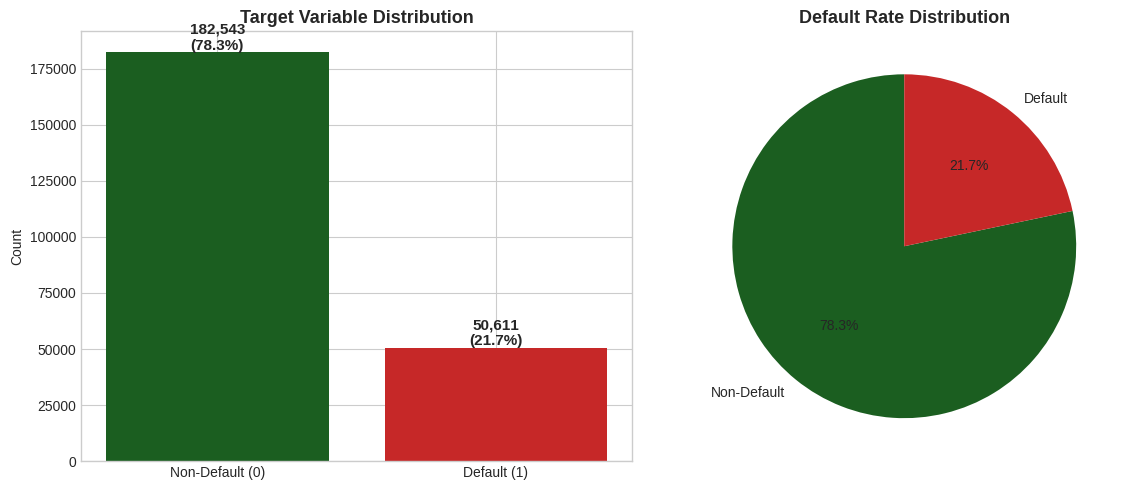

Default Rate: 21.71%


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
vals = df['loan_default'].value_counts()
axes[0].bar(['Non-Default (0)', 'Default (1)'],
            vals.values, color=['#1B5E20', '#C62828'])
for i, (val, pct) in enumerate(zip(vals.values, vals.values/len(df)*100)):
    axes[0].text(i, val+1000, f'{val:,}\n({pct:.1f}%)',
                 ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Target Variable Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')

# Pie chart
axes[1].pie(vals.values, labels=['Non-Default', 'Default'],
            autopct='%1.1f%%', colors=['#1B5E20', '#C62828'],
            startangle=90)
axes[1].set_title('Default Rate Distribution', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Default Rate: {df["loan_default"].mean()*100:.2f}%')

## Step 6 — Target Variable Across Categories

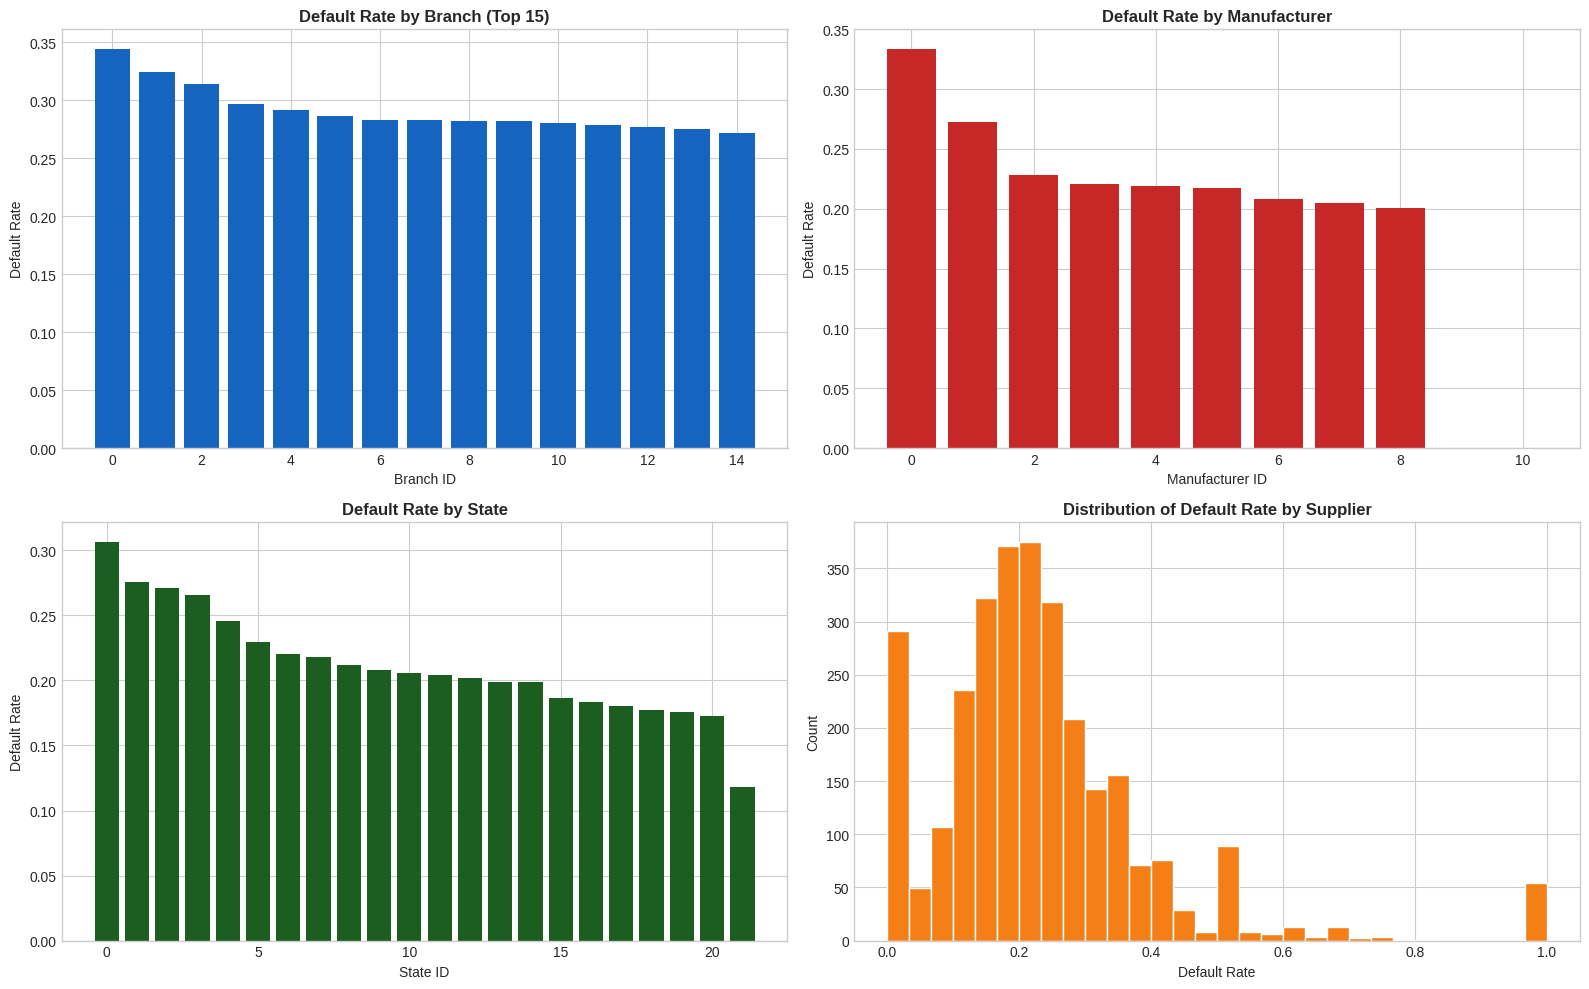

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# By Branch
branch_def = df.groupby('branch_id')['loan_default'].mean().sort_values(ascending=False).head(15)
axes[0,0].bar(range(len(branch_def)), branch_def.values, color='#1565C0')
axes[0,0].set_title('Default Rate by Branch (Top 15)', fontweight='bold')
axes[0,0].set_xlabel('Branch ID'); axes[0,0].set_ylabel('Default Rate')

# By Manufacturer
mfr_def = df.groupby('manufacturer_id')['loan_default'].mean().sort_values(ascending=False)
axes[0,1].bar(range(len(mfr_def)), mfr_def.values, color='#C62828')
axes[0,1].set_title('Default Rate by Manufacturer', fontweight='bold')
axes[0,1].set_xlabel('Manufacturer ID'); axes[0,1].set_ylabel('Default Rate')

# By State
state_def = df.groupby('state_id')['loan_default'].mean().sort_values(ascending=False)
axes[1,0].bar(range(len(state_def)), state_def.values, color='#1B5E20')
axes[1,0].set_title('Default Rate by State', fontweight='bold')
axes[1,0].set_xlabel('State ID'); axes[1,0].set_ylabel('Default Rate')

# By Supplier
sup_def = df.groupby('supplier_id')['loan_default'].mean()
axes[1,1].hist(sup_def.values, bins=30, color='#F57F17', edgecolor='white')
axes[1,1].set_title('Distribution of Default Rate by Supplier', fontweight='bold')
axes[1,1].set_xlabel('Default Rate'); axes[1,1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('default_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 7 — Employment Type Analysis

Employment Types:
employment_type
Self employed    135296
Salaried          97858
Name: count, dtype: int64


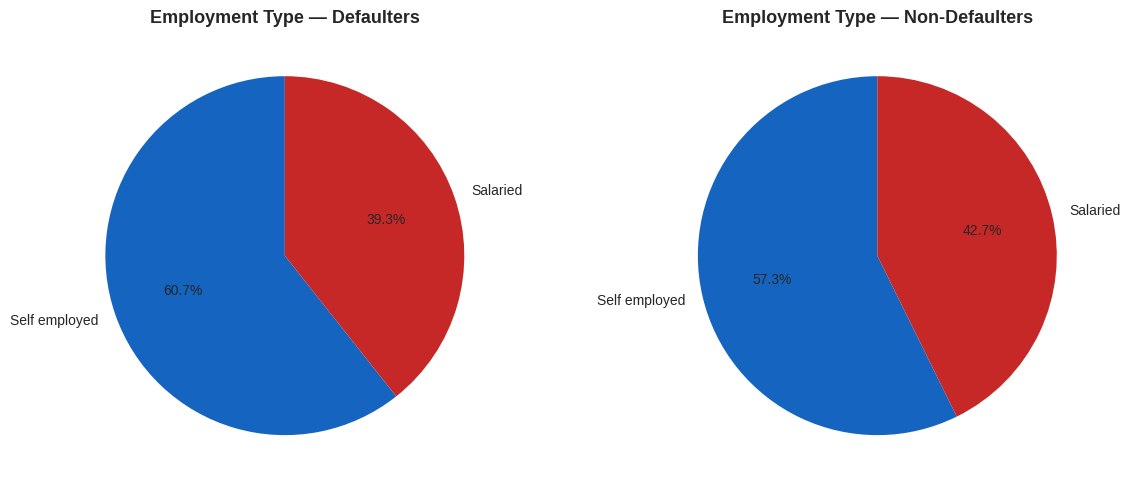

In [13]:
print('Employment Types:')
print(df['employment_type'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Defaulters
def_emp = df[df['loan_default']==1]['employment_type'].value_counts()
axes[0].pie(def_emp.values, labels=def_emp.index,
            autopct='%1.1f%%', colors=['#1565C0','#C62828','#F57F17'],
            startangle=90)
axes[0].set_title('Employment Type — Defaulters', fontsize=13, fontweight='bold')

# Non-Defaulters
nondef_emp = df[df['loan_default']==0]['employment_type'].value_counts()
axes[1].pie(nondef_emp.values, labels=nondef_emp.index,
            autopct='%1.1f%%', colors=['#1565C0','#C62828','#F57F17'],
            startangle=90)
axes[1].set_title('Employment Type — Non-Defaulters', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('employment_type.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 8 — Age Distribution vs Default

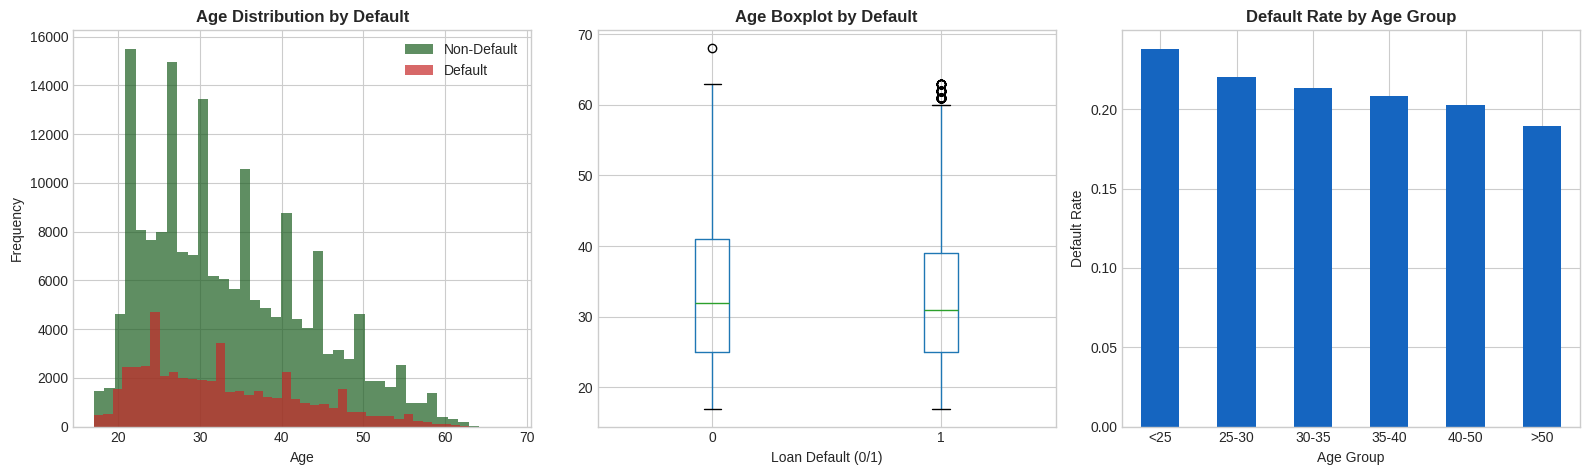

Avg Age - Defaulters:     32.7
Avg Age - Non-Defaulters: 33.5


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Histogram
df[df['loan_default']==0]['age'].plot(
    kind='hist', bins=40, ax=axes[0],
    color='#1B5E20', alpha=0.7, label='Non-Default')
df[df['loan_default']==1]['age'].plot(
    kind='hist', bins=40, ax=axes[0],
    color='#C62828', alpha=0.7, label='Default')
axes[0].set_title('Age Distribution by Default', fontweight='bold')
axes[0].set_xlabel('Age'); axes[0].legend()

# Boxplot
df.boxplot(column='age', by='loan_default', ax=axes[1])
axes[1].set_title('Age Boxplot by Default', fontweight='bold')
axes[1].set_xlabel('Loan Default (0/1)')
plt.suptitle('')

# Age groups
df['age_group'] = pd.cut(df['age'],
    bins=[0,25,30,35,40,50,100],
    labels=['<25','25-30','30-35','35-40','40-50','>50'])
age_def = df.groupby('age_group')['loan_default'].mean()
age_def.plot(kind='bar', ax=axes[2], color='#1565C0')
axes[2].set_title('Default Rate by Age Group', fontweight='bold')
axes[2].set_xlabel('Age Group'); axes[2].set_ylabel('Default Rate')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('age_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Avg Age - Defaulters:     {df[df["loan_default"]==1]["age"].mean():.1f}')
print(f'Avg Age - Non-Defaulters: {df[df["loan_default"]==0]["age"].mean():.1f}')

## Step 9 — ID Proof Types

ID Proof Type Counts:
  Mobile No      : 233,154 (100.0%)
  Aadhar         : 195,924 (84.0%)
  PAN            : 17,621 (7.6%)
  Voter ID       : 33,794 (14.5%)
  Driving Lic    : 5,419 (2.3%)
  Passport       : 496 (0.2%)


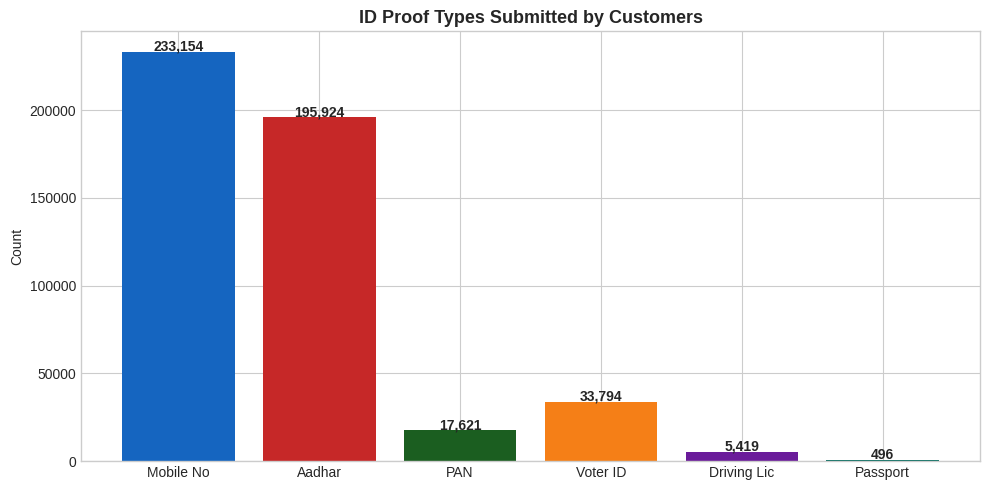

In [15]:
id_cols  = ['mobileno_avl_flag','aadhar_flag','pan_flag',
            'voterid_flag','driving_flag','passport_flag']
id_names = ['Mobile No','Aadhar','PAN','Voter ID','Driving Lic','Passport']
id_counts = [df[c].sum() for c in id_cols]
id_pct    = [c/len(df)*100 for c in id_counts]

print('ID Proof Type Counts:')
for name, cnt, pct in zip(id_names, id_counts, id_pct):
    print(f'  {name:15}: {cnt:,} ({pct:.1f}%)')

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#1565C0','#C62828','#1B5E20','#F57F17','#6A1B9A','#00695C']
bars = ax.bar(id_names, id_counts, color=colors)
for bar, val in zip(bars, id_counts):
    ax.text(bar.get_x()+bar.get_width()/2, val+500,
            f'{val:,}', ha='center', fontsize=10, fontweight='bold')
ax.set_title('ID Proof Types Submitted by Customers',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('id_proof.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 10 — Credit Bureau Score Analysis

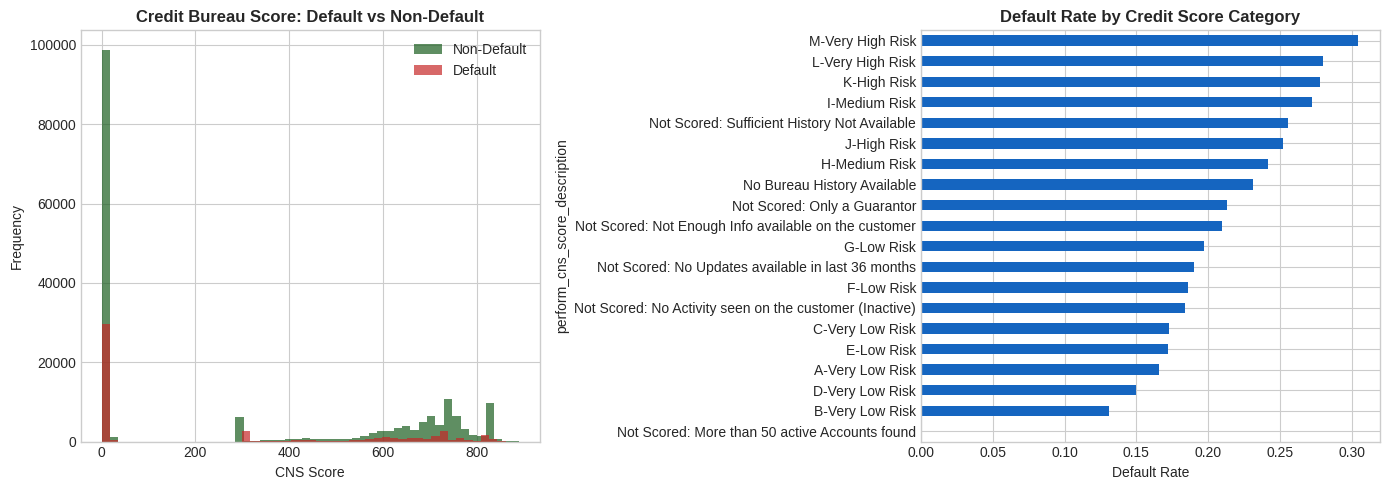

Default rate by CNS Score Description:
perform_cns_score_description
M-Very High Risk                                           0.305
L-Very High Risk                                           0.280
K-High Risk                                                0.278
I-Medium Risk                                              0.273
Not Scored: Sufficient History Not Available               0.256
J-High Risk                                                0.252
H-Medium Risk                                              0.242
No Bureau History Available                                0.231
Not Scored: Only a Guarantor                               0.213
Not Scored: Not Enough Info available on the customer      0.210
G-Low Risk                                                 0.197
Not Scored: No Updates available in last 36 months         0.190
F-Low Risk                                                 0.186
Not Scored: No Activity seen on the customer (Inactive)    0.184
C-Very Low Risk      

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Score distribution
df[df['loan_default']==0]['perform_cns_score'].plot(
    kind='hist', bins=50, ax=axes[0],
    color='#1B5E20', alpha=0.7, label='Non-Default')
df[df['loan_default']==1]['perform_cns_score'].plot(
    kind='hist', bins=50, ax=axes[0],
    color='#C62828', alpha=0.7, label='Default')
axes[0].set_title('Credit Bureau Score: Default vs Non-Default',
                  fontweight='bold')
axes[0].set_xlabel('CNS Score'); axes[0].legend()

# Default rate by score category
score_def = df.groupby('perform_cns_score_description')['loan_default']\
              .mean().sort_values(ascending=True)
score_def.plot(kind='barh', ax=axes[1], color='#1565C0')
axes[1].set_title('Default Rate by Credit Score Category',
                  fontweight='bold')
axes[1].set_xlabel('Default Rate')

plt.tight_layout()
plt.savefig('credit_score.png', dpi=150, bbox_inches='tight')
plt.show()

print('Default rate by CNS Score Description:')
print(df.groupby('perform_cns_score_description')['loan_default']\
      .mean().sort_values(ascending=False).round(3))

## Step 11 — Primary & Secondary Account Analysis

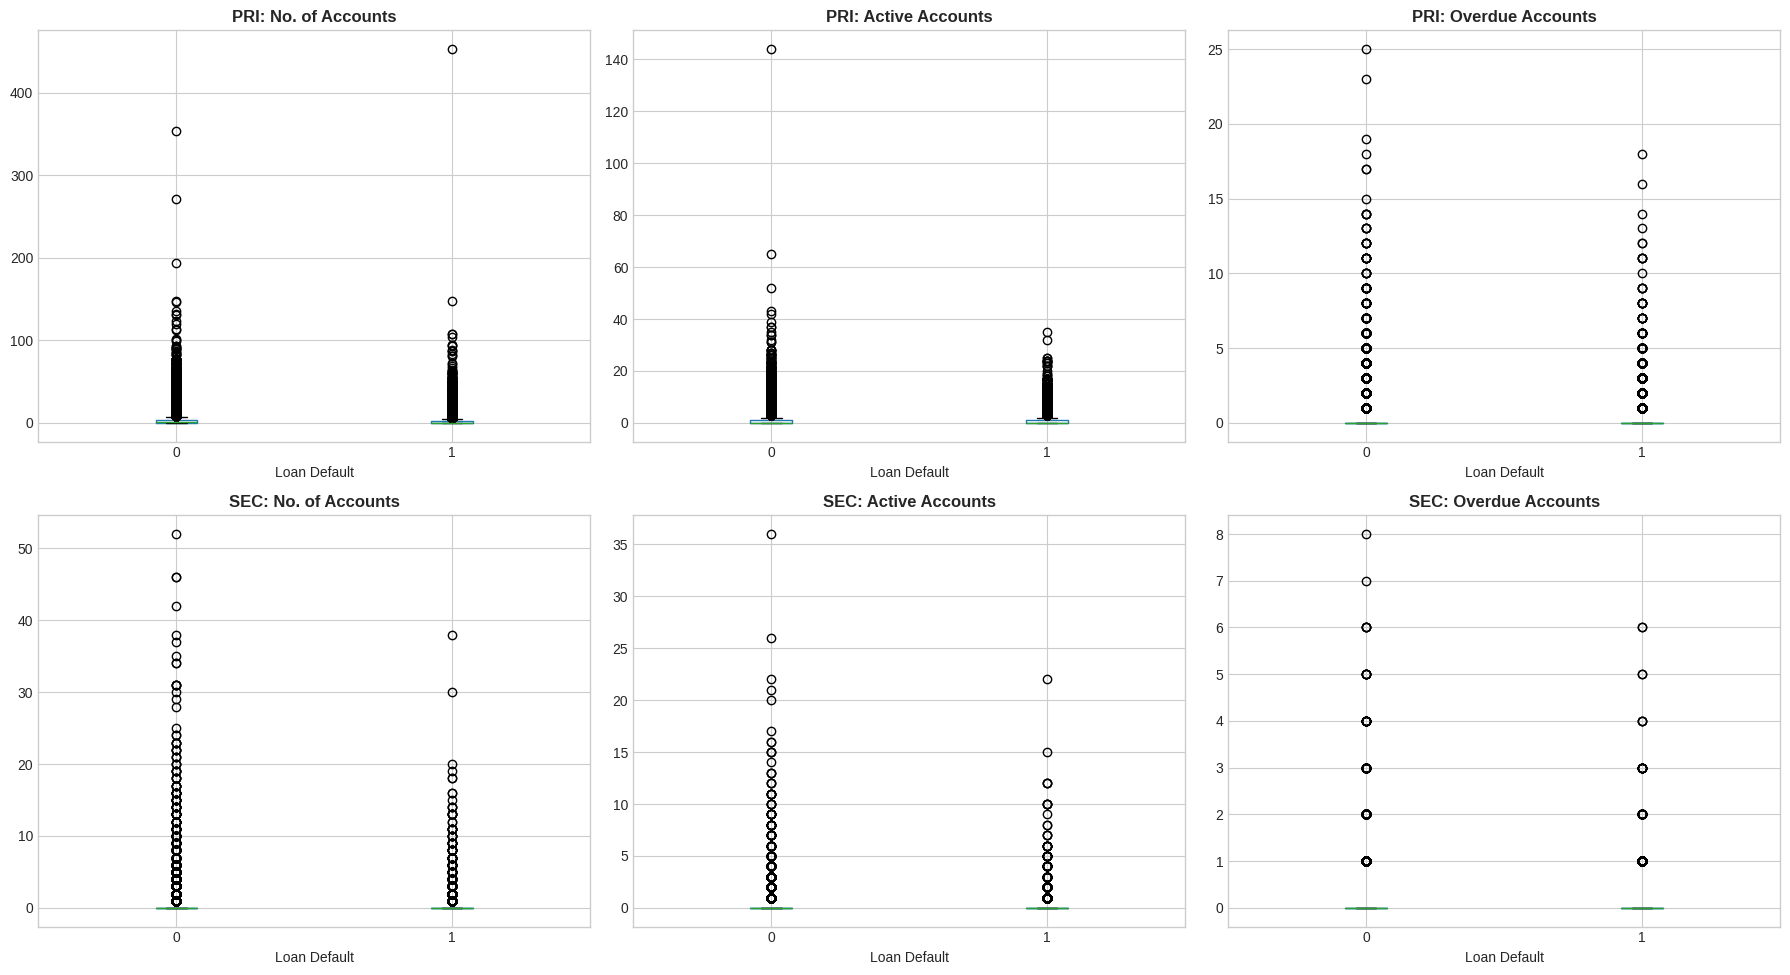

Primary Account Stats by Default:
              pri_no_of_accts  pri_active_accts  pri_overdue_accts
loan_default                                                      
0                        2.54              1.08               0.14
1                        2.09              0.89               0.20


In [17]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

pri_cols = ['pri_no_of_accts','pri_active_accts','pri_overdue_accts']
sec_cols = ['sec_no_of_accts','sec_active_accts','sec_overdue_accts']
titles_p = ['PRI: No. of Accounts','PRI: Active Accounts','PRI: Overdue Accounts']
titles_s = ['SEC: No. of Accounts','SEC: Active Accounts','SEC: Overdue Accounts']

for i, (col, title) in enumerate(zip(pri_cols, titles_p)):
    df.boxplot(column=col, by='loan_default', ax=axes[0,i])
    axes[0,i].set_title(title, fontweight='bold')
    axes[0,i].set_xlabel('Loan Default')
    plt.suptitle('')

for i, (col, title) in enumerate(zip(sec_cols, titles_s)):
    df.boxplot(column=col, by='loan_default', ax=axes[1,i])
    axes[1,i].set_title(title, fontweight='bold')
    axes[1,i].set_xlabel('Loan Default')
    plt.suptitle('')

plt.tight_layout()
plt.savefig('account_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('Primary Account Stats by Default:')
print(df.groupby('loan_default')[pri_cols].mean().round(2))

## Step 12 — Sanctioned vs Disbursed Amount

Primary Loan Amounts:
       pri_sanctioned_amount  pri_disbursed_amount
count           2.331540e+05          2.331540e+05
mean            2.185039e+05          2.180659e+05
std             2.374794e+06          2.377744e+06
min             0.000000e+00          0.000000e+00
25%             0.000000e+00          0.000000e+00
50%             0.000000e+00          0.000000e+00
75%             6.250000e+04          6.080000e+04
max             1.000000e+09          1.000000e+09

Secondary Loan Amounts:
       sec_sanctioned_amount  sec_disbursed_amount
count              233154.00              233154.0
mean                 7295.92                7180.0
std                183155.99              182592.5
min                     0.00                   0.0
25%                     0.00                   0.0
50%                     0.00                   0.0
75%                     0.00                   0.0
max              30000000.00            30000000.0

Difference (Sanctioned - Disbursed

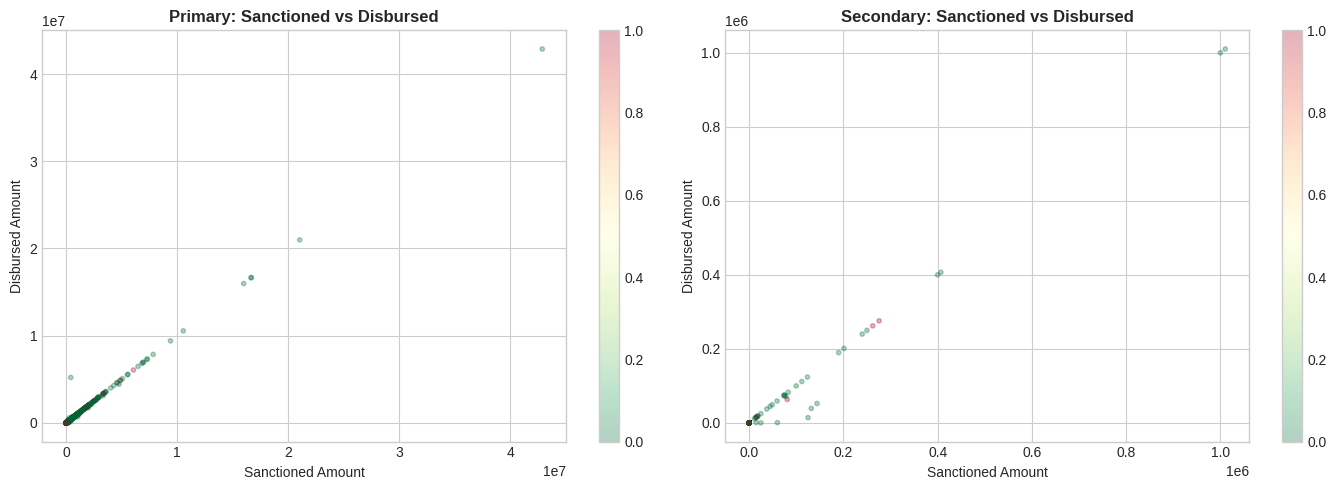

In [18]:
# Statistics
print('Primary Loan Amounts:')
print(df[['pri_sanctioned_amount','pri_disbursed_amount']]\
      .describe().round(2))

print('\nSecondary Loan Amounts:')
print(df[['sec_sanctioned_amount','sec_disbursed_amount']]\
      .describe().round(2))

print('\nDifference (Sanctioned - Disbursed):')
df['pri_diff'] = df['pri_sanctioned_amount'] - df['pri_disbursed_amount']
df['sec_diff'] = df['sec_sanctioned_amount'] - df['sec_disbursed_amount']
print('Primary Diff:', df['pri_diff'].describe().round(2))
print('Secondary Diff:', df['sec_diff'].describe().round(2))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sample = df.sample(3000, random_state=42)

sc1 = axes[0].scatter(sample['pri_sanctioned_amount'],
                      sample['pri_disbursed_amount'],
                      c=sample['loan_default'],
                      cmap='RdYlGn_r', alpha=0.3, s=10)
axes[0].set_title('Primary: Sanctioned vs Disbursed', fontweight='bold')
axes[0].set_xlabel('Sanctioned Amount')
axes[0].set_ylabel('Disbursed Amount')
plt.colorbar(sc1, ax=axes[0])

sc2 = axes[1].scatter(sample['sec_sanctioned_amount'],
                      sample['sec_disbursed_amount'],
                      c=sample['loan_default'],
                      cmap='RdYlGn_r', alpha=0.3, s=10)
axes[1].set_title('Secondary: Sanctioned vs Disbursed', fontweight='bold')
axes[1].set_xlabel('Sanctioned Amount')
axes[1].set_ylabel('Disbursed Amount')
plt.colorbar(sc2, ax=axes[1])

plt.tight_layout()
plt.savefig('sanctioned_disbursed.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 13 — Inquiries vs Default Risk

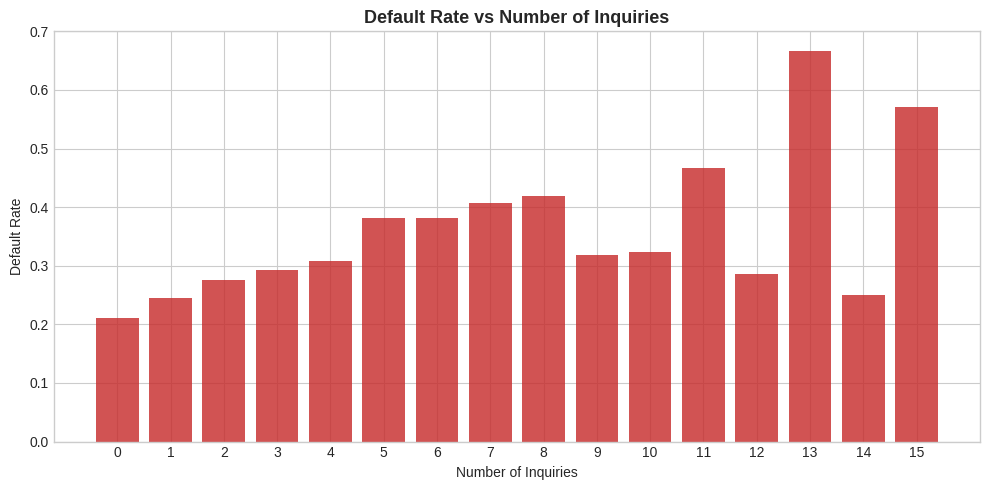


Correlation with loan_default:
loan_default                           1.000
no_of_inquiries                        0.044
pri_overdue_accts                      0.041
delinquent_accts_in_last_six_months    0.034
sec_overdue_accts                     -0.001
new_accts_in_last_six_months          -0.029
Name: loan_default, dtype: float64


In [19]:
inq = df.groupby('no_of_inquiries')['loan_default']\
        .mean().reset_index()
inq = inq[inq['no_of_inquiries'] <= 15]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(inq['no_of_inquiries'], inq['loan_default'],
       color='#C62828', alpha=0.8)
ax.set_title('Default Rate vs Number of Inquiries',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Inquiries')
ax.set_ylabel('Default Rate')
ax.set_xticks(inq['no_of_inquiries'])
plt.tight_layout()
plt.savefig('inquiries.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nCorrelation with loan_default:')
credit_cols = ['no_of_inquiries','new_accts_in_last_six_months',
               'delinquent_accts_in_last_six_months',
               'pri_overdue_accts','sec_overdue_accts']
print(df[credit_cols + ['loan_default']]\
      .corr()['loan_default'].sort_values(ascending=False).round(3))

## Step 14 — Logistic Regression Modeling

In [20]:
# Encode Employment Type
df['emp_encoded'] = (df['employment_type'] == 'Salaried').astype(int)

# Select features
features = [
    'disbursed_amount', 'asset_cost', 'ltv', 'age', 'emp_encoded',
    'perform_cns_score', 'pri_no_of_accts', 'pri_active_accts',
    'pri_overdue_accts', 'pri_current_balance', 'pri_sanctioned_amount',
    'pri_disbursed_amount', 'sec_no_of_accts', 'sec_overdue_accts',
    'new_accts_in_last_six_months', 'delinquent_accts_in_last_six_months',
    'no_of_inquiries', 'aadhar_flag', 'pan_flag', 'voterid_flag'
]

X = df[features].fillna(0)
y = df['loan_default']

# Train-test split (70-30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

print(f'Train size: {len(X_train):,}')
print(f'Test size:  {len(X_test):,}')

Train size: 163,207
Test size:  69,947


In [21]:
# Scale features
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# Train model
lr = LogisticRegression(max_iter=500, random_state=42)
lr.fit(X_train_s, y_train)

# Predict
y_pred = lr.predict(X_test_s)
y_prob = lr.predict_proba(X_test_s)[:, 1]

print('Model trained successfully!')

Model trained successfully!


## Step 15 — Model Evaluation & Confusion Matrix

In [22]:
# Classification Report
print('Classification Report:')
print(classification_report(y_test, y_pred,
      target_names=['Non-Default','Default']))

# ROC-AUC
roc = roc_auc_score(y_test, y_prob)
print(f'ROC-AUC Score: {roc:.4f}')

Classification Report:
              precision    recall  f1-score   support

 Non-Default       0.79      1.00      0.88     55052
     Default       0.38      0.00      0.01     14895

    accuracy                           0.79     69947
   macro avg       0.58      0.50      0.44     69947
weighted avg       0.70      0.79      0.69     69947

ROC-AUC Score: 0.6182


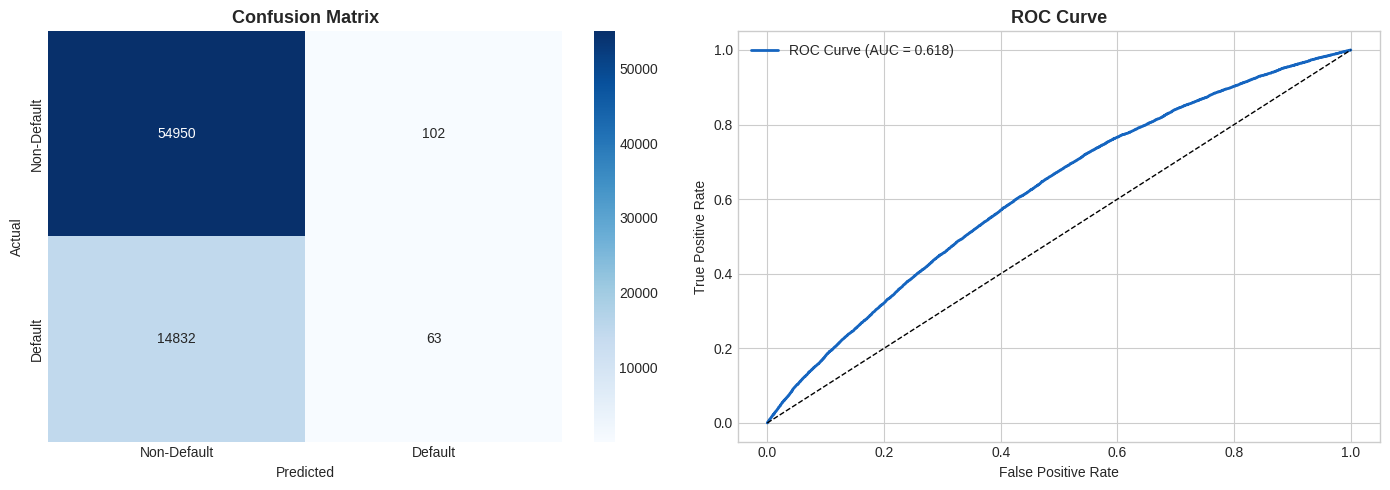

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Non-Default','Default'],
            yticklabels=['Non-Default','Default'])
axes[0].set_title('Confusion Matrix', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='#1565C0', lw=2,
             label=f'ROC Curve (AUC = {roc:.3f})')
axes[1].plot([0,1],[0,1], 'k--', lw=1)
axes[1].set_title('ROC Curve', fontsize=13, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

plt.tight_layout()
plt.savefig('model_results.png', dpi=150, bbox_inches='tight')
plt.show()

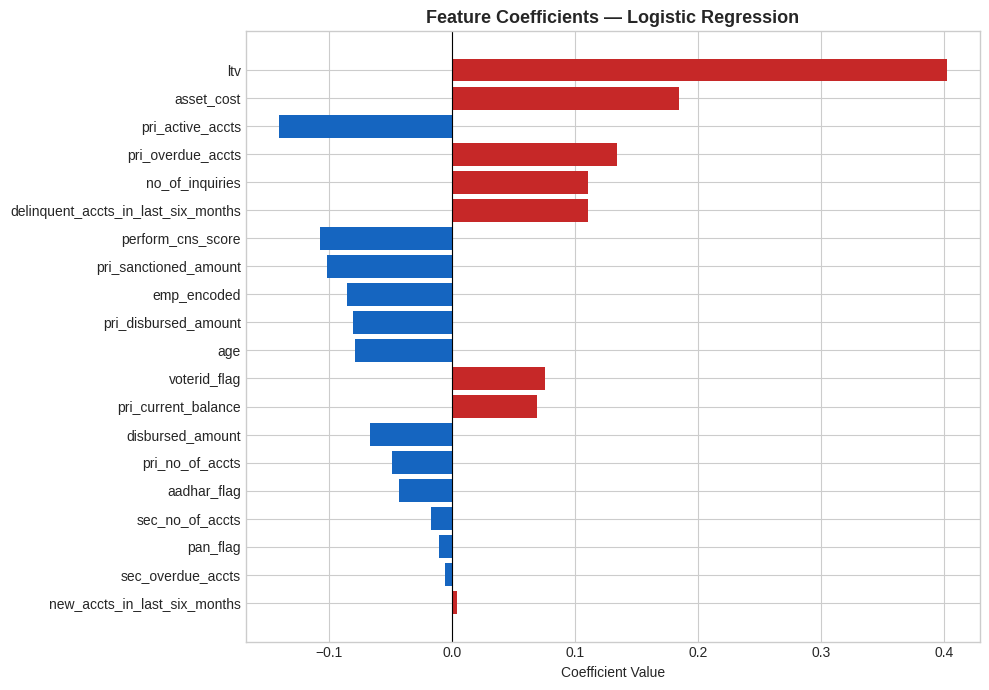


Top Risk Factors (Positive Coefficients):
                                Feature  Coefficient
2                                   ltv     0.401826
1                            asset_cost     0.184533
8                     pri_overdue_accts     0.133901
16                      no_of_inquiries     0.110494
15  delinquent_accts_in_last_six_months     0.110015
19                         voterid_flag     0.075308
9                   pri_current_balance     0.069197
14         new_accts_in_last_six_months     0.003844

Protective Factors (Negative Coefficients):
                  Feature  Coefficient
7        pri_active_accts    -0.140777
5       perform_cns_score    -0.107613
10  pri_sanctioned_amount    -0.101810
4             emp_encoded    -0.085488
11   pri_disbursed_amount    -0.080481
3                     age    -0.079068
0        disbursed_amount    -0.066756
6         pri_no_of_accts    -0.049188
17            aadhar_flag    -0.043002
12        sec_no_of_accts    -0.017586
18    

In [24]:
# Feature Importance
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': lr.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#C62828' if c > 0 else '#1565C0'
          for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Coefficients — Logistic Regression',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Coefficient Value')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop Risk Factors (Positive Coefficients):')
print(coef_df[coef_df['Coefficient']>0].sort_values(
    'Coefficient', ascending=False)[['Feature','Coefficient']].to_string())

print('\nProtective Factors (Negative Coefficients):')
print(coef_df[coef_df['Coefficient']<0].sort_values(
    'Coefficient')[['Feature','Coefficient']].to_string())

## Summary
---
| Metric | Value |
|---|---|
| Total Records | 233,154 |
| Default Rate | 21.7% |
| Model Accuracy | 79% |
| ROC-AUC | 0.618 |
| Top Risk Factor | Delinquent Accounts + Inquiries |
| Top Protective Factor | CNS Score + Salaried Employment |

**Next Steps:**
- Apply SMOTE to handle class imbalance
- Try XGBoost / Random Forest for better recall
- Feature engineering (credit utilization ratio)
- Hyperparameter tuning